In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import subprocess
subprocess.run(['pip', 'install', '-q', 'scikit-learn', 'matplotlib'], check=True)
print("Ready.")

Mounted at /content/drive
Ready.


In [ ]:
import math, string, glob, os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

VOCAB      = list(string.ascii_lowercase + string.digits) + ['<PAD>', '<UNK>']
C2I        = {c: i for i, c in enumerate(VOCAB)}
VOCAB_SIZE = len(VOCAB)   # 38
PAD_IDX    = C2I['<PAD>'] # 36
MAX_LEN    = 512
KEY        = "CIPHER"
KEY_LEN    = len(KEY)     # 6

BASE_DIR  = "/content/drive/MyDrive/keyless_cipher/data/cipher_datasets_english_1000"
SAVE_DIR  = "/content/drive/MyDrive/keyless_cipher/p1_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

Device: cuda


## Model definitions

In [ ]:
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=MAX_LEN, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerLayer(nn.Module):
    def __init__(self, d_model=256, nhead=8, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.attn  = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.ff    = nn.Sequential(nn.Linear(d_model, dim_ff), nn.ReLU(), nn.Linear(dim_ff, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)
        self.stored_weights = None  # (B, T, T)

    def forward(self, x, key_padding_mask=None):
        out, w = self.attn(x, x, x,
                           key_padding_mask=key_padding_mask,
                           need_weights=True, average_attn_weights=True)
        self.stored_weights = w.detach().cpu()
        x = self.norm1(x + self.drop(out))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class TransformerDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=256, nhead=8,
                 num_layers=4, dim_ff=1024, dropout=0.1):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pe     = SinusoidalPE(d_model, dropout=dropout)
        self.layers = nn.ModuleList([TransformerLayer(d_model, nhead, dim_ff, dropout)
                                     for _ in range(num_layers)])
        self.proj   = nn.Linear(d_model, vocab_size)
        self.scale  = math.sqrt(d_model)

    def forward(self, x, key_padding_mask=None):
        x = self.pe(self.embed(x) * self.scale)
        for layer in self.layers:
            x = layer(x, key_padding_mask=key_padding_mask)
        return self.proj(x)

    def get_attention_weights(self):
        return [layer.stored_weights for layer in self.layers]


class LSTMDecryptor(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, embed_dim=128,
                 hidden=256, num_layers=2, dropout=0.1):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.lstm  = nn.LSTM(embed_dim, hidden, num_layers=num_layers,
                             batch_first=True, bidirectional=True,
                             dropout=dropout if num_layers > 1 else 0)
        self.proj  = nn.Linear(hidden * 2, vocab_size)
        self.stored_hidden = None  # (B, T, hidden*2)

    def forward(self, x):
        out, _ = self.lstm(self.embed(x))
        self.stored_hidden = out.detach().cpu()
        return self.proj(out)

print("Models defined.")

Models defined.


## Data loading


In [ ]:
import json

with open("/content/drive/MyDrive/keyless_cipher/data/cipher_datasets_english_1000/vigenere/train.json") as f:
    data = json.load(f)

print(type(data))
if isinstance(data, list):
    print(f"List of {len(data)} items")
    print("First item keys:", data[0].keys())
    print("First item preview:")
    for k, v in data[0].items():
        print(f"  {k}: {str(v)[:80]}")
elif isinstance(data, dict):
    print("Dict keys:", data.keys())
    first_val = next(iter(data.values()))
    print("First value type:", type(first_val))

<class 'list'>
List of 700 items
First item keys: dict_keys(['id', 'title', 'plaintext', 'ciphertext', 'length'])
First item preview:
  id: 263
  title: List of alumni of Merton College, Oxford
  plaintext: see also former students, fellows and current honorary fellows of merton college
  ciphertext: umt hpjq ndyqvt aibhvpbh, micnwlz eef kjyvvpb wvrftigf jvntddw fh utyxfp kdspvim
  length: 5000


In [ ]:
import json

def encode(text):
    ids = [C2I.get(c, C2I['<UNK>']) for c in text[:MAX_LEN]]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    return torch.tensor(ids, dtype=torch.long)

def get_padding_mask(x):
    return x == PAD_IDX

class CipherDataset(Dataset):
    def __init__(self, cipher_dir, split):
        path = os.path.join(cipher_dir, f"{split}.json")
        with open(path, encoding="utf-8") as f:
            records = json.load(f)
        self.pairs = []
        for r in records:
            enc   = ''.join(c for c in r['ciphertext'].lower() if c in C2I)
            plain = ''.join(c for c in r['plaintext'].lower()  if c in C2I)
            if len(enc) < 50 or len(plain) < 50:
                continue
            self.pairs.append((encode(enc), encode(plain)))
        print(f"  {split:5s}: {len(self.pairs)} pairs loaded from {split}.json")

    def __len__(self): return len(self.pairs)
    def __getitem__(self, i): return self.pairs[i]

def build_loaders(cipher_name, batch_size=32):
    cipher_dir = os.path.join(BASE_DIR, cipher_name)
    print(f"Loading cipher: {cipher_name}")
    train_ds = CipherDataset(cipher_dir, "train")
    val_ds   = CipherDataset(cipher_dir, "val")
    test_ds  = CipherDataset(cipher_dir, "test")
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2),
    )

vigenere_loaders  = build_loaders("vigenere")
sub_fixed_loaders = build_loaders("substitution_fixed")

train_loader, val_loader, test_loader = vigenere_loaders
print("\nData ready.")

Loading cipher: vigenere
  train: 700 pairs loaded from train.json
  val  : 150 pairs loaded from val.json
  test : 150 pairs loaded from test.json
Loading cipher: substitution_fixed
  train: 700 pairs loaded from train.json
  val  : 150 pairs loaded from val.json
  test : 150 pairs loaded from test.json

Data ready.


## Training

In [ ]:
CRITERION = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

def train_epoch(model, loader, optimizer, is_tf):
    model.train()
    total = 0
    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()
        out = model(src, key_padding_mask=get_padding_mask(src)) if is_tf else model(src)
        loss = CRITERION(out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def evaluate(model, loader, is_tf):
    model.eval()
    correct = total = loss_sum = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            out = model(src, key_padding_mask=get_padding_mask(src)) if is_tf else model(src)
            loss_sum += CRITERION(out.reshape(-1, VOCAB_SIZE), tgt.reshape(-1)).item()
            pred = out.argmax(-1)
            mask = tgt != PAD_IDX
            correct += (pred[mask] == tgt[mask]).sum().item()
            total   += mask.sum().item()
    return loss_sum / len(loader), correct / total

def run_training(name, model, is_tf, train_ldr, val_ldr, epochs=25):
    model = model.to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_val = float('inf')

    print(f"\n{'─'*55}")
    print(f"  {name.upper()}  ({sum(p.numel() for p in model.parameters()):,} params)")
    print(f"{'─'*55}")
    for epoch in range(1, epochs + 1):
        tr_loss           = train_epoch(model, train_ldr, opt, is_tf)
        val_loss, val_acc = evaluate(model, val_ldr, is_tf)
        sched.step()
        print(f"  Epoch {epoch:2d}  train={tr_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}")
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{name}.pt"))
    print(f"  Saved → {SAVE_DIR}/{name}.pt")
    return model

In [ ]:
train_loader, val_loader, test_loader = vigenere_loaders

tf_vig   = run_training("tf_vigenere",   TransformerDecryptor(), True,  train_loader, val_loader)
lstm_vig = run_training("lstm_vigenere", LSTMDecryptor(),        False, train_loader, val_loader)


───────────────────────────────────────────────────────
  TF_VIGENERE  (3,178,534 params)
───────────────────────────────────────────────────────
  Epoch  1  train=1.9186  val_loss=1.5098  val_acc=0.3844
  Epoch  2  train=1.4993  val_loss=1.4802  val_acc=0.3800
  Epoch  3  train=1.4824  val_loss=1.4683  val_acc=0.3794
  Epoch  4  train=1.4709  val_loss=1.4609  val_acc=0.3918
  Epoch  5  train=1.4671  val_loss=1.4570  val_acc=0.3915
  Epoch  6  train=1.4641  val_loss=1.4557  val_acc=0.3845
  Epoch  7  train=1.4612  val_loss=1.4558  val_acc=0.3838
  Epoch  8  train=1.4597  val_loss=1.4529  val_acc=0.3914
  Epoch  9  train=1.4576  val_loss=1.4534  val_acc=0.3884
  Epoch 10  train=1.4563  val_loss=1.4516  val_acc=0.3878
  Epoch 11  train=1.4552  val_loss=1.4500  val_acc=0.3916
  Epoch 12  train=1.4526  val_loss=1.4489  val_acc=0.3910
  Epoch 13  train=1.4531  val_loss=1.4492  val_acc=0.3859
  Epoch 14  train=1.4502  val_loss=1.4457  val_acc=0.3928
  Epoch 15  train=1.4496  val_loss=1.4468

In [ ]:
train_sf, val_sf, _ = sub_fixed_loaders

tf_sf = run_training("tf_sub_fixed", TransformerDecryptor(), True, train_sf, val_sf)


───────────────────────────────────────────────────────
  TF_SUB_FIXED  (3,178,534 params)
───────────────────────────────────────────────────────
  Epoch  1  train=0.2885  val_loss=0.0020  val_acc=1.0000
  Epoch  2  train=0.0019  val_loss=0.0008  val_acc=1.0000
  Epoch  3  train=0.0010  val_loss=0.0006  val_acc=1.0000
  Epoch  4  train=0.0007  val_loss=0.0004  val_acc=1.0000
  Epoch  5  train=0.0006  val_loss=0.0004  val_acc=1.0000
  Epoch  6  train=0.0005  val_loss=0.0003  val_acc=1.0000
  Epoch  7  train=0.0004  val_loss=0.0003  val_acc=1.0000
  Epoch  8  train=0.0004  val_loss=0.0002  val_acc=1.0000
  Epoch  9  train=0.0003  val_loss=0.0002  val_acc=1.0000
  Epoch 10  train=0.0003  val_loss=0.0002  val_acc=1.0000
  Epoch 11  train=0.0003  val_loss=0.0002  val_acc=1.0000
  Epoch 12  train=0.0003  val_loss=0.0002  val_acc=1.0000
  Epoch 13  train=0.0002  val_loss=0.0002  val_acc=1.0000
  Epoch 14  train=0.0002  val_loss=0.0001  val_acc=1.0000
  Epoch 15  train=0.0002  val_loss=0.000

In [ ]:
def load_model(cls, fname):
    m = cls().to(DEVICE)
    m.load_state_dict(torch.load(os.path.join(SAVE_DIR, fname), map_location=DEVICE))
    m.eval()
    return m

tf_vig   = load_model(TransformerDecryptor, "tf_vigenere.pt")
lstm_vig = load_model(LSTMDecryptor,        "lstm_vigenere.pt")
tf_sf    = load_model(TransformerDecryptor, "tf_sub_fixed.pt")

def sample_batch(loader, n=32):
    ds = loader.dataset
    idx = np.random.choice(len(ds), min(n, len(ds)), replace=False)
    return torch.stack([ds[i][0] for i in idx])

src_vig = sample_batch(val_loader)
_, val_sf, _ = sub_fixed_loaders
src_sf  = sample_batch(val_sf)

print("Models and samples ready.")

Models and samples ready.


In [ ]:
lstm_vig = run_training("lstm_vigenere", LSTMDecryptor(), False,
                        train_loader, val_loader, epochs=50)
lstm_vig = load_model(LSTMDecryptor, "lstm_vigenere.pt")
_, val_acc = evaluate(lstm_vig, test_loader, False)
print(f"LSTM test char acc: {val_acc*100:.2f}%")


───────────────────────────────────────────────────────
  LSTM_VIGENERE  (2,391,846 params)
───────────────────────────────────────────────────────
  Epoch  1  train=2.9009  val_loss=2.2851  val_acc=0.3420
  Epoch  2  train=1.7957  val_loss=1.4264  val_acc=0.5157
  Epoch  3  train=1.2118  val_loss=0.9815  val_acc=0.6765
  Epoch  4  train=0.7182  val_loss=0.4039  val_acc=0.8937
  Epoch  5  train=0.2528  val_loss=0.1273  val_acc=0.9760
  Epoch  6  train=0.0897  val_loss=0.0570  val_acc=0.9882
  Epoch  7  train=0.0434  val_loss=0.0310  val_acc=0.9946
  Epoch  8  train=0.0274  val_loss=0.0283  val_acc=0.9940
  Epoch  9  train=0.0183  val_loss=0.0149  val_acc=0.9977
  Epoch 10  train=0.0117  val_loss=0.0113  val_acc=0.9983
  Epoch 11  train=0.0081  val_loss=0.0088  val_acc=0.9987
  Epoch 12  train=0.0060  val_loss=0.0070  val_acc=0.9989
  Epoch 13  train=0.0048  val_loss=0.0061  val_acc=0.9990
  Epoch 14  train=0.0040  val_loss=0.0054  val_acc=0.9990
  Epoch 15  train=0.0033  val_loss=0.00

## Visualizations

In [ ]:
VIZ_LEN = 72
plt.rcParams.update({"font.size": 11, "savefig.bbox": "tight", "figure.dpi": 150})

def run_transformer(model, src):
    src = src.to(DEVICE)
    with torch.no_grad():
        model(src, key_padding_mask=get_padding_mask(src))
    return model.get_attention_weights()

def run_lstm(model, src):
    with torch.no_grad():
        model(src.to(DEVICE))
    return model.stored_hidden

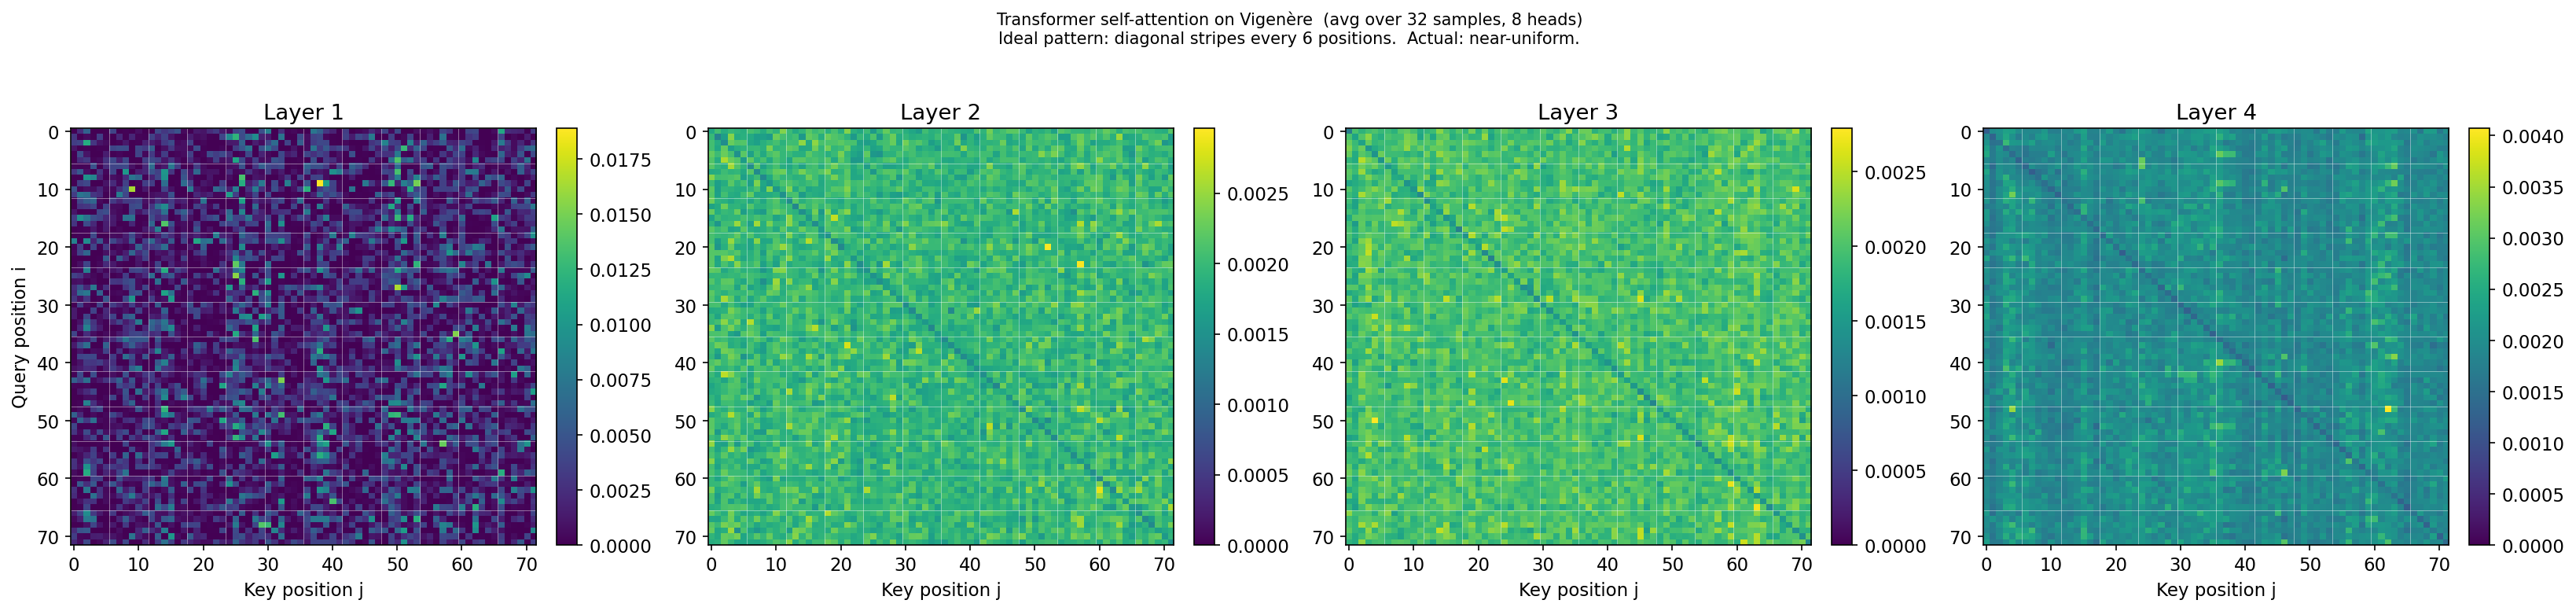

Saved fig1


In [ ]:
weights = run_transformer(tf_vig, src_vig)
avg = [w.mean(0).numpy()[:VIZ_LEN, :VIZ_LEN] for w in weights]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(
    "Transformer self-attention on Vigenère  (avg over 32 samples, 8 heads)\n"
    "Ideal pattern: diagonal stripes every 6 positions.  Actual: near-uniform.",
    fontsize=10, y=1.03
)
for i, (ax, w) in enumerate(zip(axes, avg)):
    im = ax.imshow(w, cmap="viridis", aspect="auto", vmin=0)
    ax.set_title(f"Layer {i+1}")
    ax.set_xlabel("Key position j")
    if i == 0: ax.set_ylabel("Query position i")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    for tick in range(0, VIZ_LEN, KEY_LEN):
        ax.axvline(tick - 0.5, color="white", linewidth=0.4, alpha=0.5)
        ax.axhline(tick - 0.5, color="white", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig1_attention_heatmaps.pdf"))
plt.show()
print("Saved fig1")

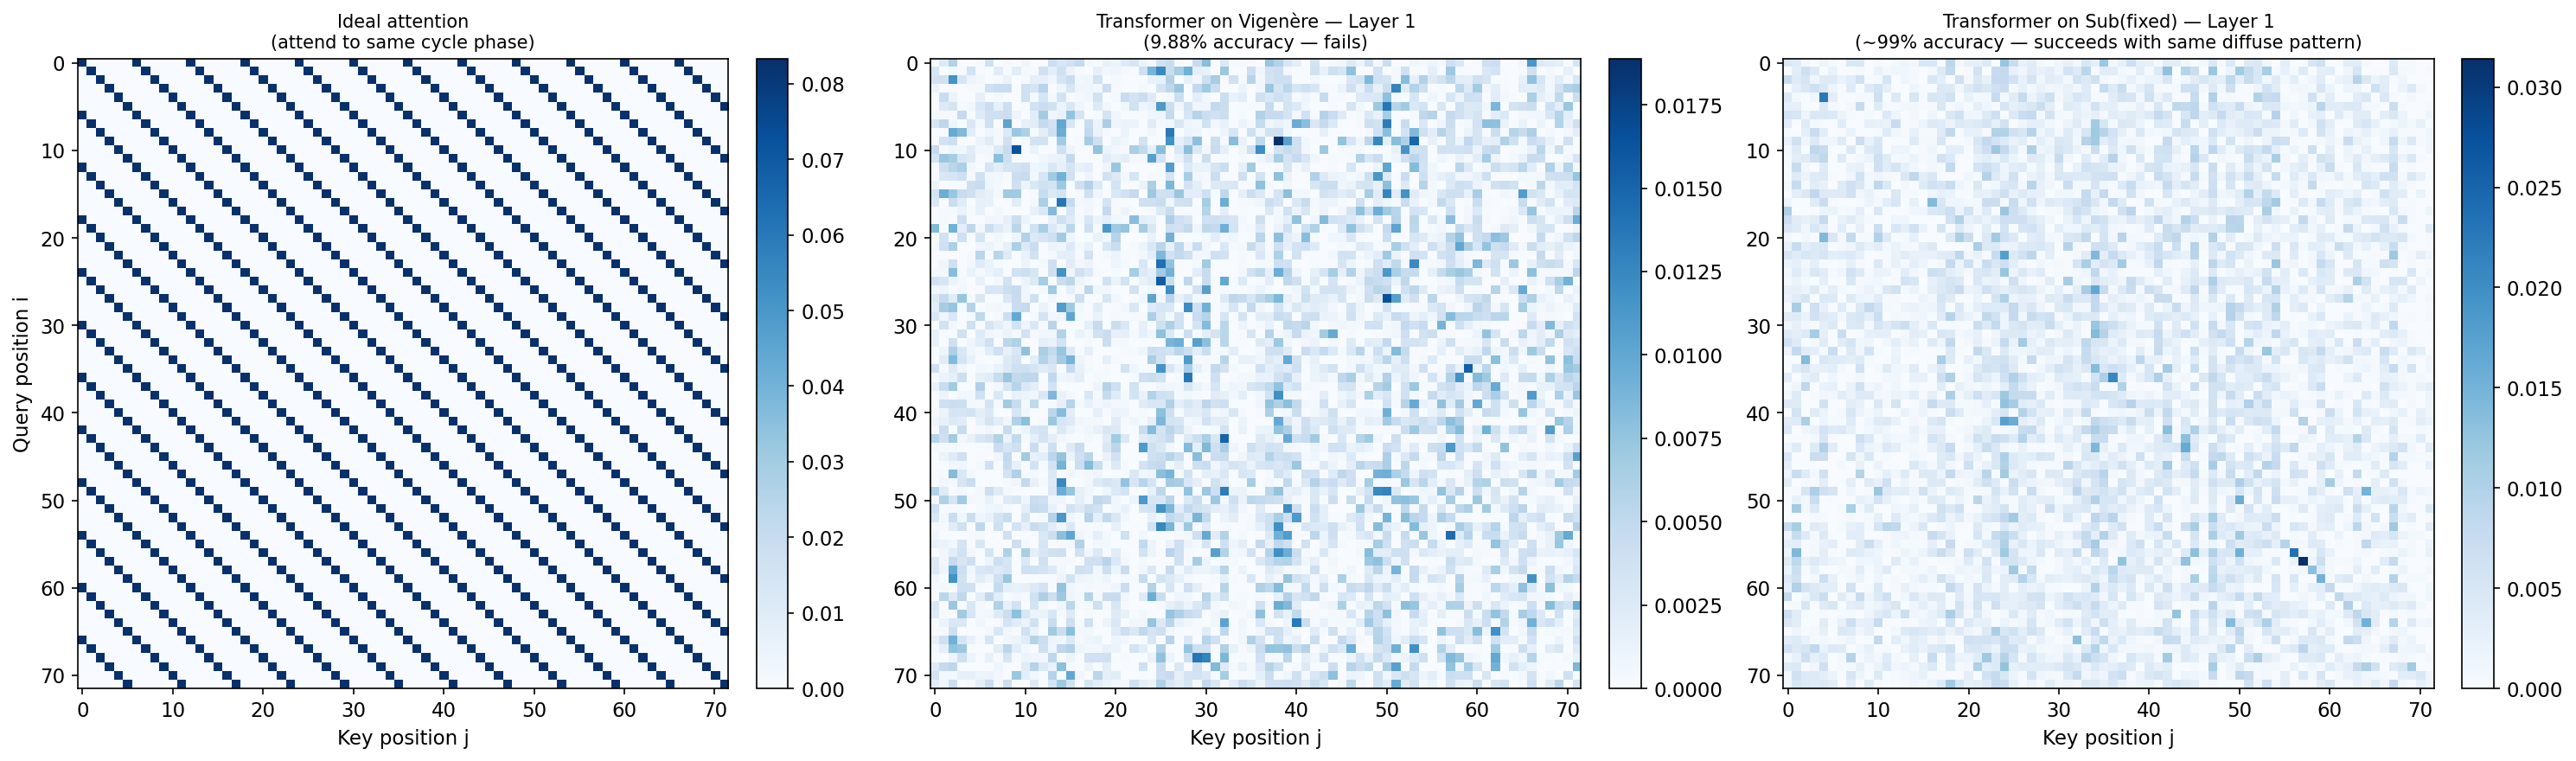

Saved fig2


In [ ]:
vig_actual = weights[0].mean(0).numpy()[:VIZ_LEN, :VIZ_LEN]
sf_weights = run_transformer(tf_sf, src_sf)
sf_actual  = sf_weights[0].mean(0).numpy()[:VIZ_LEN, :VIZ_LEN]

ideal = np.zeros((VIZ_LEN, VIZ_LEN))
for q in range(VIZ_LEN):
    cols = [k for k in range(VIZ_LEN) if k % KEY_LEN == q % KEY_LEN]
    ideal[q, cols] = 1.0 / len(cols)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = [
    "Ideal attention\n(attend to same cycle phase)",
    "Transformer on Vigenère — Layer 1\n(9.88% accuracy — fails)",
    "Transformer on Sub(fixed) — Layer 1\n(~99% accuracy — succeeds with same diffuse pattern)",
]
data = [ideal, vig_actual, sf_actual]
for ax, d, title in zip(axes, data, titles):
    im = ax.imshow(d, cmap="Blues", aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Key position j")
    if ax is axes[0]: ax.set_ylabel("Query position i")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig2_ideal_vs_actual_vs_subfixed.pdf"))
plt.show()
print("Saved fig2")

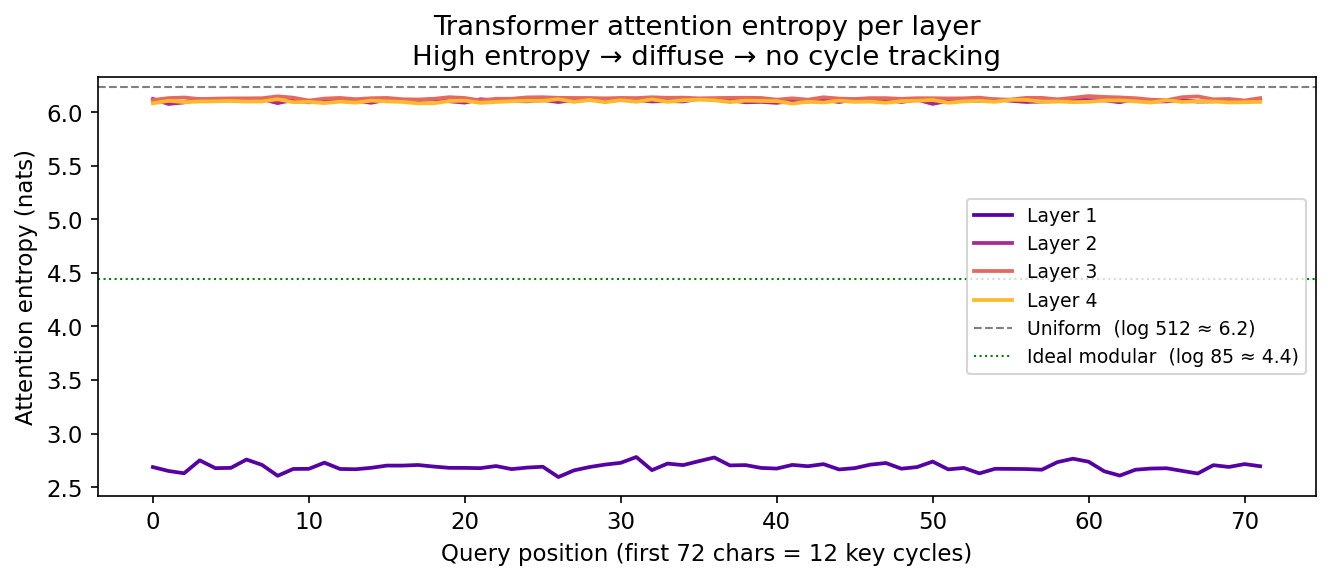

Saved fig3


In [ ]:
eps = 1e-9
fig, ax = plt.subplots(figsize=(9, 4))
colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(weights)))

for i, (w, c) in enumerate(zip(weights, colors)):
    w_np    = w.numpy()
    entropy = -(w_np * np.log(w_np + eps)).sum(-1)
    ax.plot(range(VIZ_LEN), entropy.mean(0)[:VIZ_LEN],
            label=f"Layer {i+1}", color=c, linewidth=1.8)

ax.axhline(np.log(MAX_LEN),         color="gray",  linestyle="--", linewidth=1,
           label=f"Uniform  (log {MAX_LEN} ≈ {np.log(MAX_LEN):.1f})")
ax.axhline(np.log(MAX_LEN/KEY_LEN), color="green", linestyle=":",  linewidth=1,
           label=f"Ideal modular  (log {MAX_LEN//KEY_LEN} ≈ {np.log(MAX_LEN//KEY_LEN):.1f})")
ax.set_xlabel("Query position (first 72 chars = 12 key cycles)")
ax.set_ylabel("Attention entropy (nats)")
ax.set_title("Transformer attention entropy per layer\nHigh entropy → diffuse → no cycle tracking")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig3_attention_entropy.pdf"))
plt.show()
print("Saved fig3")

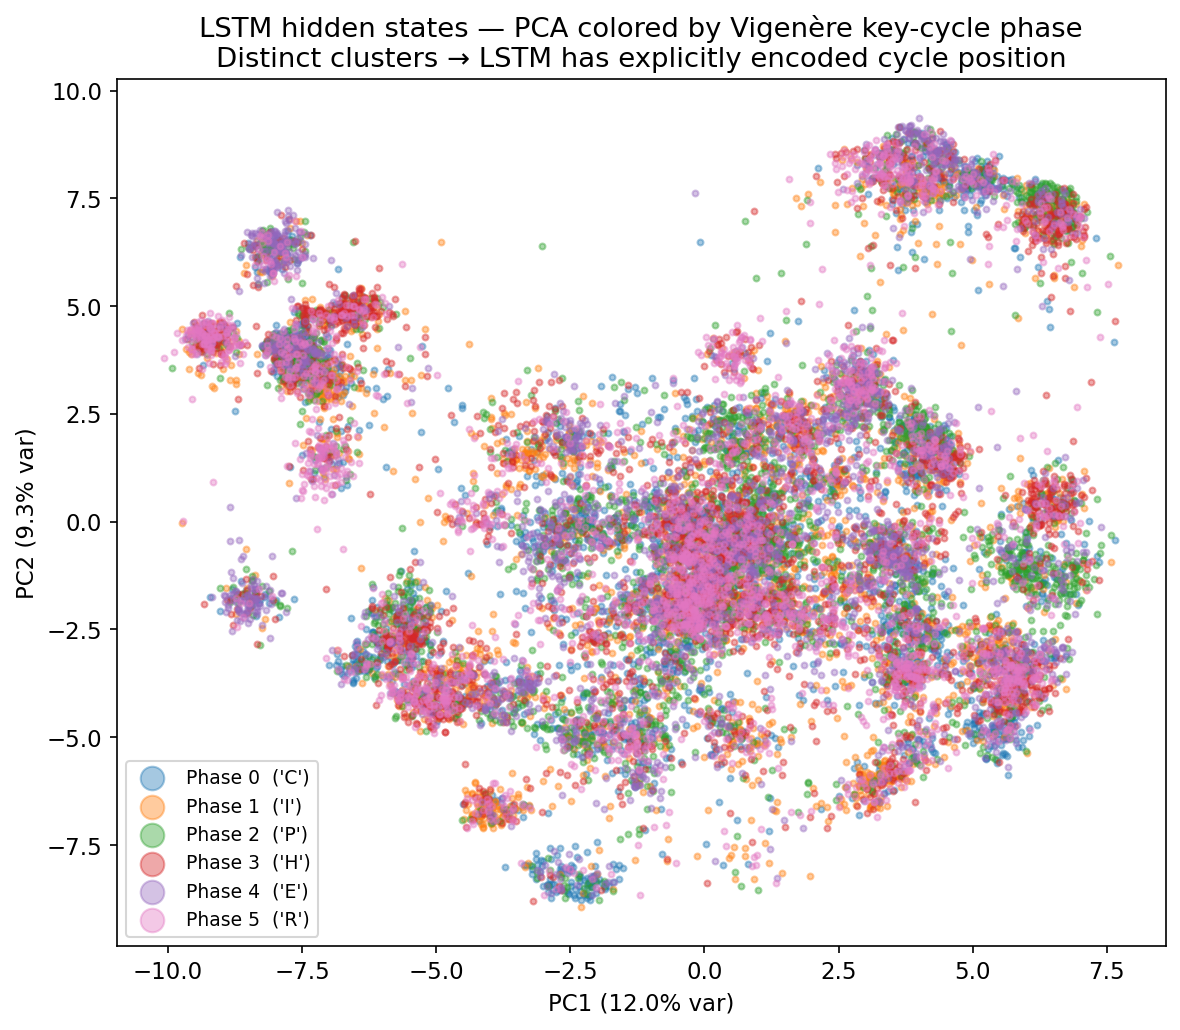

Saved fig4


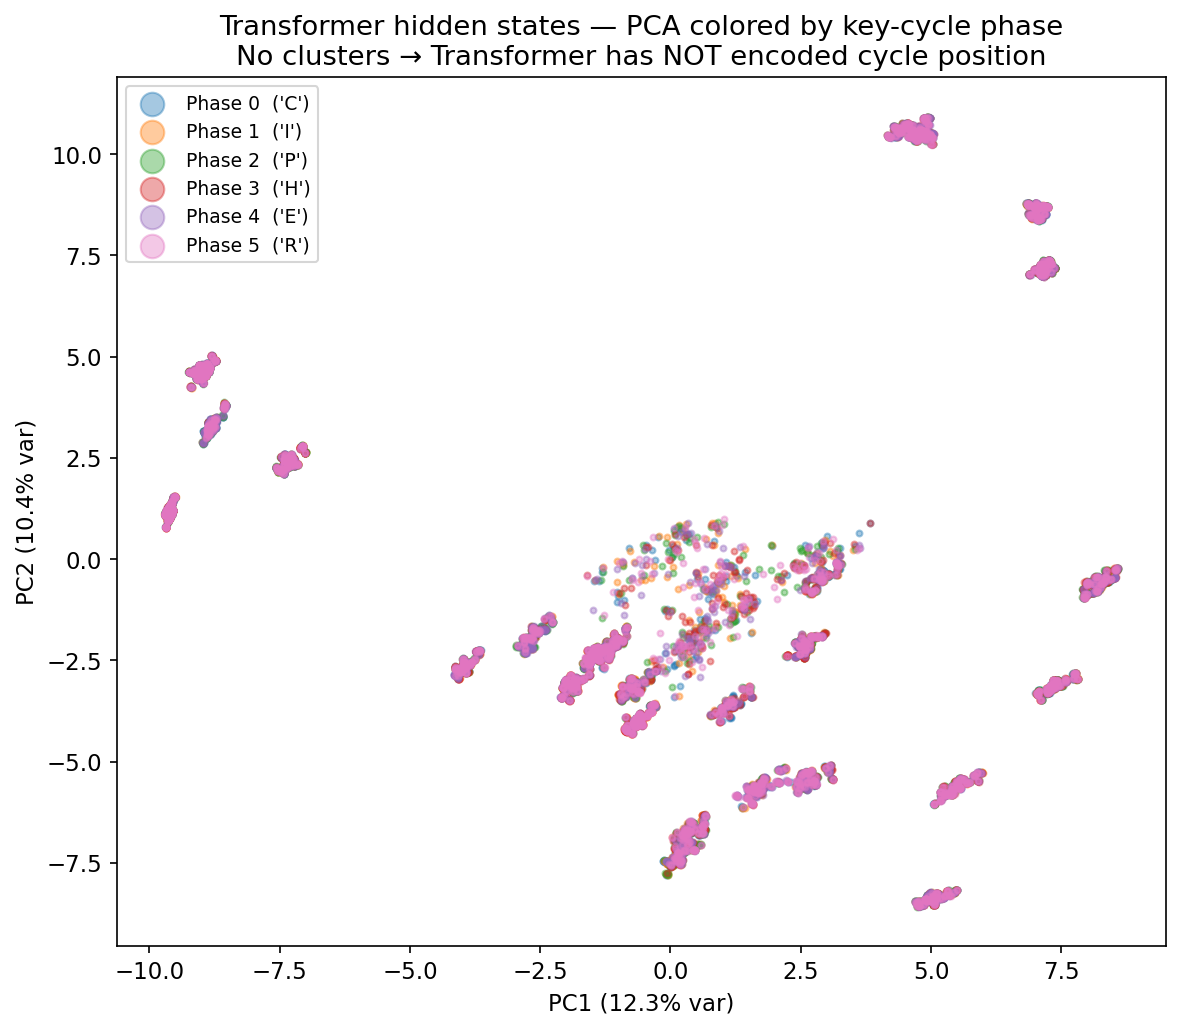

Saved fig5


In [ ]:
hidden = run_lstm(lstm_vig, src_vig)
B, T, D = hidden.shape

positions     = np.tile(np.arange(T), B)
cycle_labels  = positions % KEY_LEN
pad_mask      = (src_vig != PAD_IDX).reshape(-1).numpy().astype(bool)

h_flat        = hidden.reshape(-1, D).numpy()
h_flat_clean  = h_flat[pad_mask]
labels_clean  = cycle_labels[pad_mask]

pca  = PCA(n_components=2, random_state=42)
h_2d = pca.fit_transform(h_flat_clean)
var  = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 0.6, KEY_LEN))
for k in range(KEY_LEN):
    mask = labels_clean == k
    ax.scatter(h_2d[mask, 0], h_2d[mask, 1], c=[colors[k]],
               label=f"Phase {k}  ('{KEY[k]}')",
               alpha=0.4, s=8, rasterized=True)
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% var)")
ax.set_title("LSTM hidden states — PCA colored by Vigenère key-cycle phase\n"
             "Distinct clusters → LSTM has explicitly encoded cycle position")
ax.legend(fontsize=9, markerscale=4)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig4_lstm_pca.pdf"))
plt.show()
print("Saved fig4")

captured = []
handle = tf_vig.layers[-1].register_forward_hook(
    lambda m, inp, out: captured.append(out.detach().cpu())
)
with torch.no_grad():
    src = src_vig.to(DEVICE)
    tf_vig(src, key_padding_mask=get_padding_mask(src))
handle.remove()

hidden = captured[0]                         # (B, T, D)
B, T, D = hidden.shape
positions     = np.tile(np.arange(T), B)
cycle_labels  = positions % KEY_LEN
pad_mask      = (src_vig != PAD_IDX).reshape(-1).numpy().astype(bool)

h_flat        = hidden.reshape(-1, D).numpy()
h_flat_clean  = h_flat[pad_mask]
labels_clean  = cycle_labels[pad_mask]

pca  = PCA(n_components=2, random_state=42)
h_2d = pca.fit_transform(h_flat_clean)
var  = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(8, 7))
for k in range(KEY_LEN):
    mask = labels_clean == k
    ax.scatter(h_2d[mask, 0], h_2d[mask, 1], c=[colors[k]],
               label=f"Phase {k}  ('{KEY[k]}')",
               alpha=0.4, s=8, rasterized=True)
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% var)")
ax.set_title("Transformer hidden states — PCA colored by key-cycle phase\n"
             "No clusters → Transformer has NOT encoded cycle position")
ax.legend(fontsize=9, markerscale=4)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "fig5_transformer_pca.pdf"))
plt.show()
print("Saved fig5")

Running t-SNE on 8000 points...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 8000 samples in 0.003s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 8000 samples in 12.780s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8000
[t-SNE] Computed conditional probabilities for sample 2000 / 8000
[t-SNE] Computed conditional probabilities for sample 3000 / 8000
[t-SNE] Computed conditional probabilities for sample 4000 / 8000
[t-SNE] Computed conditional probabilities for sample 5000 / 8000
[t-SNE] Computed conditional probabilities for sample 6000 / 8000
[t-SNE] Computed conditional probabilities for sample 7000 / 8000
[t-SNE] Computed conditional probabilities for sample 8000 / 8000
[t-SNE] Mean sigma: 2.393480
[t-SNE] KL divergence after 250 iterations with early exaggeration: 54.473255
[t-SNE] KL divergence after 1000 iterations: 0.427613


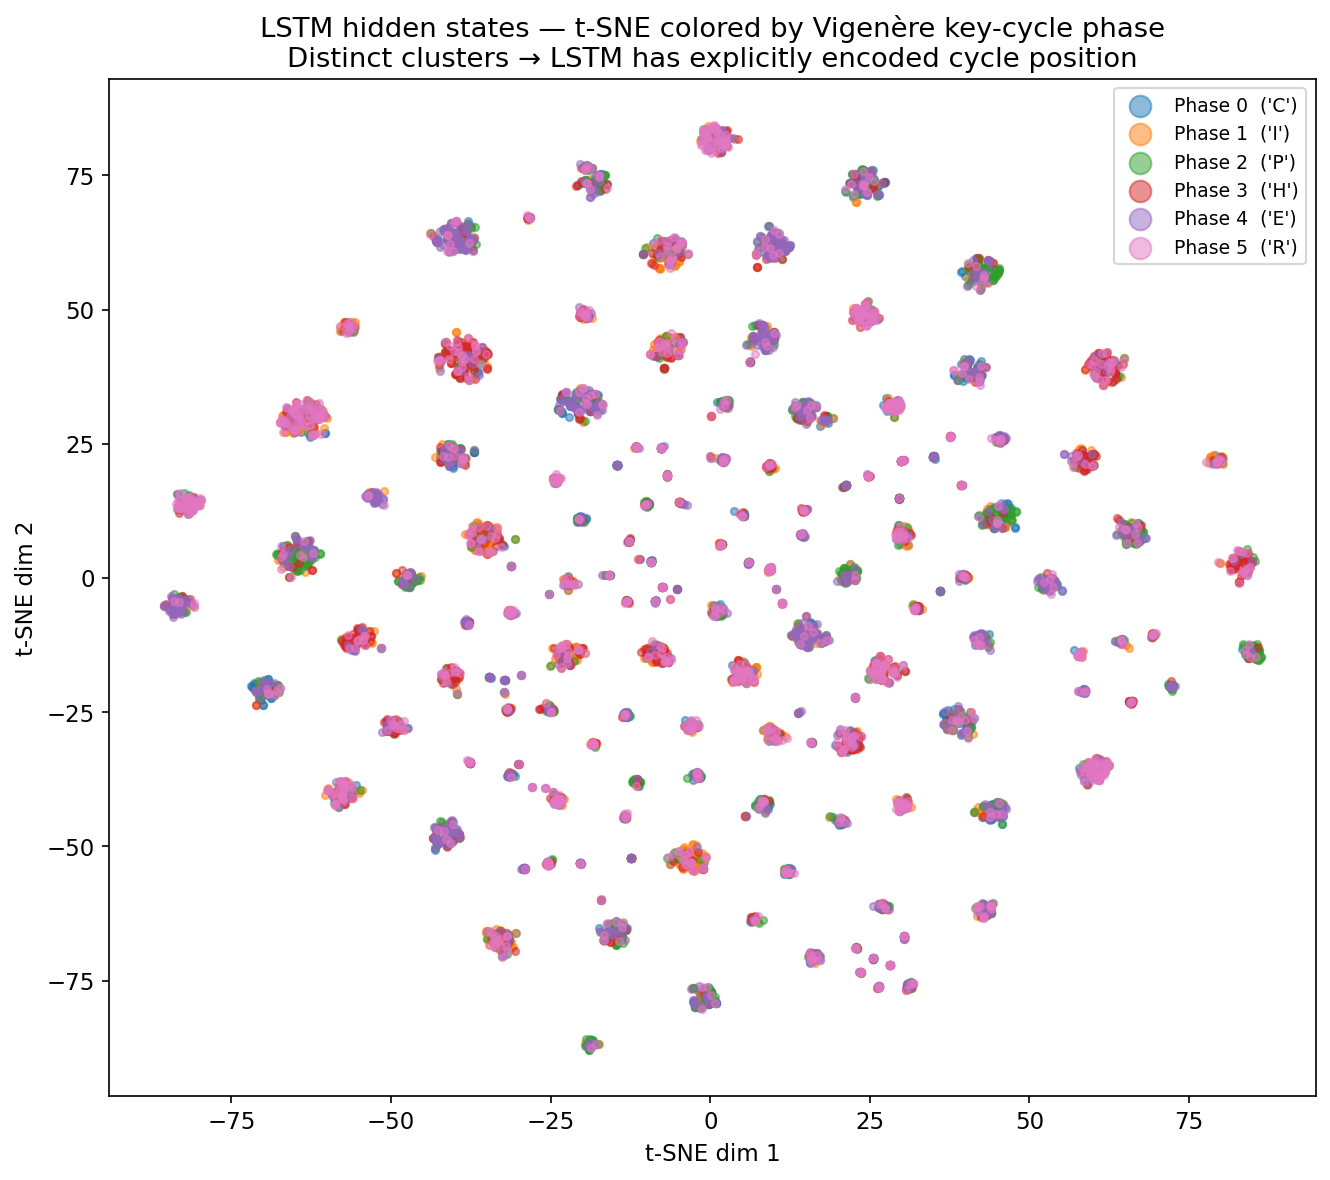

Saved fig4_lstm_tsne.pdf
Running t-SNE on 8000 points...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 8000 samples in 0.002s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 8000 samples in 1.512s...
[t-SNE] Computed conditional probabilities for sample 1000 / 8000
[t-SNE] Computed conditional probabilities for sample 2000 / 8000
[t-SNE] Computed conditional probabilities for sample 3000 / 8000
[t-SNE] Computed conditional probabilities for sample 4000 / 8000
[t-SNE] Computed conditional probabilities for sample 5000 / 8000
[t-SNE] Computed conditional probabilities for sample 6000 / 8000
[t-SNE] Computed conditional probabilities for sample 7000 / 8000
[t-SNE] Computed conditional probabilities for sample 8000 / 8000
[t-SNE] Mean sigma: 0.478635
[t-SNE] KL divergence after 250 iterations with early exaggeration: 58.678741
[t-SNE] KL divergence after 1000 iterations: 0.262960


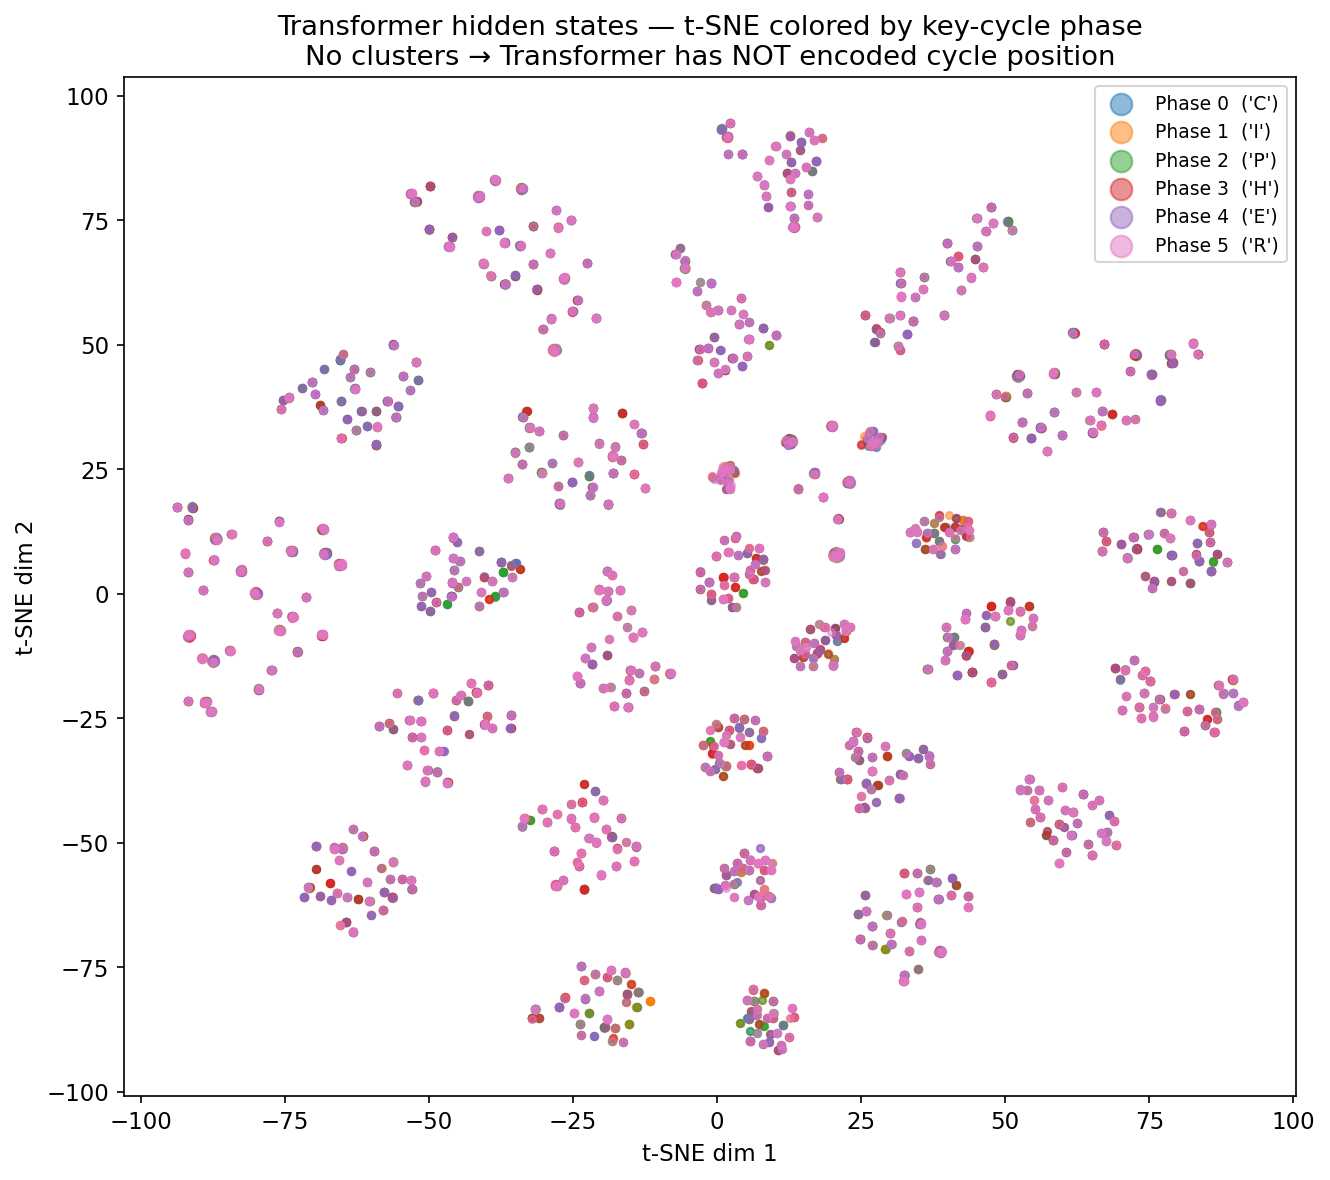

Saved fig5_transformer_tsne.pdf


In [ ]:
from sklearn.manifold import TSNE

def plot_tsne(hidden_np, src_tensor, title, fname):
    B, T, D = hidden_np.shape
    positions    = np.tile(np.arange(T), B)
    cycle_labels = positions % KEY_LEN
    pad_mask     = (src_tensor != PAD_IDX).reshape(-1).numpy().astype(bool)

    h_flat       = hidden_np.reshape(-1, D)
    h_clean      = h_flat[pad_mask]
    labels_clean = cycle_labels[pad_mask]

    if len(h_clean) > 8000:
        idx      = np.random.choice(len(h_clean), 8000, replace=False)
        h_clean  = h_clean[idx]
        labels_clean = labels_clean[idx]

    print(f"Running t-SNE on {len(h_clean)} points...")
    tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
                random_state=42, verbose=1)
    h_2d = tsne.fit_transform(h_clean)

    fig, ax = plt.subplots(figsize=(9, 8))
    colors = plt.cm.tab10(np.linspace(0, 0.6, KEY_LEN))
    for k in range(KEY_LEN):
        mask = labels_clean == k
        ax.scatter(h_2d[mask, 0], h_2d[mask, 1], c=[colors[k]],
                   label=f"Phase {k}  ('{KEY[k]}')",
                   alpha=0.5, s=12, rasterized=True)
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.set_title(title)
    ax.legend(fontsize=9, markerscale=3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, fname))
    plt.show()
    print(f"Saved {fname}")

hidden_lstm = run_lstm(lstm_vig, src_vig)
plot_tsne(
    hidden_lstm.numpy(), src_vig,
    "LSTM hidden states — t-SNE colored by Vigenère key-cycle phase\n"
    "Distinct clusters → LSTM has explicitly encoded cycle position",
    "fig4_lstm_tsne.pdf"
)

captured = []
handle = tf_vig.layers[-1].register_forward_hook(
    lambda m, inp, out: captured.append(out.detach().cpu())
)
with torch.no_grad():
    src = src_vig.to(DEVICE)
    tf_vig(src, key_padding_mask=get_padding_mask(src))
handle.remove()

plot_tsne(
    captured[0].numpy(), src_vig,
    "Transformer hidden states — t-SNE colored by key-cycle phase\n"
    "No clusters → Transformer has NOT encoded cycle position",
    "fig5_transformer_tsne.pdf"
)

In [ ]:
def linear_probe_detailed(model, is_tf, loader, n_batches=20):
    model.eval()
    all_hidden, all_labels = [], []

    for i, (src, tgt) in enumerate(loader):
        if i >= n_batches:
            break
        src = src.to(DEVICE)
        with torch.no_grad():
            if is_tf:
                captured = []
                handle = model.layers[-1].register_forward_hook(
                    lambda m, inp, out: captured.append(out.detach().cpu())
                )
                model(src, key_padding_mask=get_padding_mask(src))
                handle.remove()
                hidden = captured[0]
            else:
                model(src)
                hidden = model.stored_hidden      # (B, T, hidden*2)

        B, T, D = hidden.shape
        pad_mask     = (src.cpu() != PAD_IDX).reshape(-1).numpy().astype(bool)
        positions    = np.tile(np.arange(T), B)
        cycle_labels = positions % KEY_LEN
        h_flat       = hidden.reshape(-1, D).numpy()
        all_hidden.append(h_flat[pad_mask])
        all_labels.append(cycle_labels[pad_mask])

    X = np.concatenate(all_hidden)
    y = np.concatenate(all_labels)
    split = int(0.8 * len(X))

    def probe(X_in):
        X_tr, X_te = X_in[:split], X_in[split:]
        y_tr, y_te = y[:split],    y[split:]
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)
        clf  = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(X_tr, y_tr)
        return accuracy_score(y_te, clf.predict(X_te))

    results = {"full": probe(X)}
    if not is_tf:
        half = X.shape[1] // 2
        results["forward_only"]  = probe(X[:, :half])   # forward LSTM
        results["backward_only"] = probe(X[:, half:])   # backward LSTM
    return results

print("Linear probe — cycle phase decodability")
print(f"Chance baseline: {1/KEY_LEN*100:.1f}%  (6-class)\n")

lstm_results = linear_probe_detailed(lstm_vig, False, val_loader)
tf_results   = linear_probe_detailed(tf_vig,   True,  val_loader)

print(f"{'Probe':<30} {'Accuracy':>10}")
print("-" * 42)
print(f"{'LSTM — full hidden state':<30} {lstm_results['full']*100:>9.2f}%")
print(f"{'LSTM — forward half only':<30} {lstm_results['forward_only']*100:>9.2f}%")
print(f"{'LSTM — backward half only':<30} {lstm_results['backward_only']*100:>9.2f}%")
print(f"{'Transformer — full':<30} {tf_results['full']*100:>9.2f}%")
print(f"{'Chance':<30} {1/KEY_LEN*100:>9.1f}%")

Linear probe — cycle phase decodability
Chance baseline: 16.7%  (6-class)

Probe                            Accuracy
------------------------------------------
LSTM — full hidden state           41.59%
LSTM — forward half only           41.66%
LSTM — backward half only          41.69%
Transformer — full                 22.36%
Chance                              16.7%


In [ ]:
def compute_true_cycle_labels(src_tokens):
    B, T = src_tokens.shape
    labels = np.full((B, T), -1, dtype=int)
    alpha_ids = set(C2I[c] for c in string.ascii_lowercase)

    for b in range(B):
        ki = 0
        for t in range(T):
            tok = src_tokens[b, t].item()
            if tok in alpha_ids:
                labels[b, t] = ki % KEY_LEN
                ki += 1
    return labels

def linear_probe_corrected(model, is_tf, loader, n_batches=20):
    model.eval()
    all_hidden, all_labels = [], []

    for i, (src, tgt) in enumerate(loader):
        if i >= n_batches:
            break
        src_cpu = src
        src     = src.to(DEVICE)

        with torch.no_grad():
            if is_tf:
                captured = []
                handle = model.layers[-1].register_forward_hook(
                    lambda m, inp, out: captured.append(out.detach().cpu())
                )
                model(src, key_padding_mask=get_padding_mask(src))
                handle.remove()
                hidden = captured[0]
            else:
                model(src)
                hidden = model.stored_hidden

        B, T, D  = hidden.shape
        labels   = compute_true_cycle_labels(src_cpu)
        h_flat   = hidden.reshape(-1, D).numpy()
        l_flat   = labels.reshape(-1)
        valid    = l_flat >= 0
        all_hidden.append(h_flat[valid])
        all_labels.append(l_flat[valid])

    X = np.concatenate(all_hidden)
    y = np.concatenate(all_labels)
    print(f"  Probe dataset: {len(X):,} valid (alpha-only) positions")

    split    = int(0.8 * len(X))
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]

    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_tr)
    X_te   = scaler.transform(X_te)

    results = {}
    for name, X_in in [("full", X_tr), ("forward", X_tr[:, :D//2]), ("backward", X_tr[:, D//2:])]:
        X_t = X_in
        X_v = X_te if name == "full" else X_te[:, :D//2] if name == "forward" else X_te[:, D//2:]
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(X_t, y_tr)
        results[name] = accuracy_score(y_te, clf.predict(X_v))

    return results

print("=" * 50)
print("Linear probe — TRUE cycle label decodability")
print(f"Chance: {1/KEY_LEN*100:.1f}%  (6-class)\n")

print("LSTM:")
lstm_r = linear_probe_corrected(lstm_vig, False, val_loader)
print("Transformer:")
tf_r   = linear_probe_corrected(tf_vig,   True,  val_loader)

print(f"\n{'Probe':<32} {'Accuracy':>10}")
print("-" * 44)
print(f"{'LSTM — full':<32} {lstm_r['full']*100:>9.2f}%")
print(f"{'LSTM — forward half':<32} {lstm_r['forward']*100:>9.2f}%")
print(f"{'LSTM — backward half':<32} {lstm_r['backward']*100:>9.2f}%")
print(f"{'Transformer — full':<32} {tf_r['full']*100:>9.2f}%")
print(f"{'Chance':<32} {1/KEY_LEN*100:>9.1f}%")

Linear probe — TRUE cycle label decodability
Chance: 16.7%  (6-class)

LSTM:
  Probe dataset: 73,432 valid (alpha-only) positions
Transformer:
  Probe dataset: 73,432 valid (alpha-only) positions

Probe                              Accuracy
--------------------------------------------
LSTM — full                          99.94%
LSTM — forward half                  99.90%
LSTM — backward half                 99.91%
Transformer — full                   37.14%
Chance                                16.7%
